In [1]:
import numpy as np
from pymdp.agent import Agent
from pymdp.control import calc_expected_utility, calc_states_info_gain_factorized, get_expected_obs_factorized, get_expected_states_interactions
from pymdp.maths import softmax, softmax_obj_arr, spm_dot, spm_wnorm, spm_MDP_G, spm_log_single, kl_div, entropy, spm_cross
from pymdp import utils
import copy


import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio
from itertools import product
import random
import IPython.display as ip
from PIL import Image, ImageDraw, ImageFont

# reproducibility
random.seed(0)
np.random.seed(0)

In [71]:
# Create danger/safety context agent

n_danger = 2 # Danger states (NO DANGER, DANGER)
n_threat_obs = 10
n_obs_joint = 2 * n_threat_obs # [0-19] (no threat/threat)*(distance (0-9))

# A observation model (likelihood): P(obs | danger)
p_correct = 0.9
distance_threshold = 3

A_D = np.zeros((n_obs_joint, n_danger), dtype=float)

for i in range(n_obs_joint // 2): # no threat * dist
    A_D[i, 0] = p_correct # no danger
    A_D[i, 1] = 1 - p_correct

for i in range(n_obs_joint // 2, (n_obs_joint // 2) + distance_threshold):
    A_D[i, 0] = 1 - p_correct
    A_D[i, 1] = p_correct # in danger when distance_threshold steps away (0, 1)

for i in range((n_obs_joint // 2) + distance_threshold, n_obs_joint):
    A_D[i, 0] = p_correct
    A_D[i, 1] = 1 - p_correct

A_D = A_D / A_D.sum(axis=0, keepdims=True)

A_D_obj = np.empty(1, dtype=object); A_D_obj[0] = A_D

# control 0 = no-scale, control 1 = apply-scale (aims to push system toward safe)
D_control_scales = {
    0: (1.0, 1.0),   # no scaling (threat_scale, shelter_scale)
    1: (5.0, 20.0),   # danger scaling: stronger negative utility for threat (but we model causal effect below)
}
n_controls_D = len(D_control_scales)

# Build B transition model with shape (S_next, S_current, n_controls_D)
# B_high[s_next, s_current, c] = P(s_next | s_current, control=c)
B_D = np.zeros((n_danger, n_danger, n_controls_D), dtype=float)

# Control 0: identity (no intervention)
for s in range(n_danger):
    B_D[s, s, 0] = 1.0

# Control 1: intervention that tends to move the system to SAFE in the next step
#  P(next=safe | current=safe, control=1)   = 0.99
#  P(next=danger | current=safe, control=1) = 0.01
#  P(next=safe | current=danger, control=1) = 0.95
#  P(next=danger | current=danger, control=1) = 0.05
B_D[0, 0, 1] = 0.99   # safe -> safe
B_D[1, 0, 1] = 0.01
B_D[0, 1, 1] = 0.95   # danger -> safe (intervention helps resolve danger)
B_D[1, 1, 1] = 0.05

B_D_obj = np.empty(1, dtype=object)
B_D_obj[0] = B_D

# D_high prior (uniform)
D_D = np.array([0.5, 0.5], dtype=float)
D_D_obj = np.empty(1, dtype=object); D_D_obj[0] = D_D

# utility should not matter in this case????????????
T_D = 1
# U_D = np.ones(n_obs_joint) / n_obs_joint
U_D = np.zeros(n_obs_joint)
for i in range(n_obs_joint // 2, (n_obs_joint // 2) + distance_threshold):
    U_D[i] = -5.0
C_D_vec = np.log(softmax(U_D))
# shape (n_obs_high, T_high), using T_high=1
C_D = C_D_vec[:, None].repeat(T_D, axis=1)
C_D_obj = np.empty(1, dtype=object); C_D_obj[0] = C_D

# High-level agent action helper - scale low-level C from base
U_threat_base = []
U_shelter_base = []
U_agent_base = []
policy_len = 1

def build_scaled_C(scale):
    if isinstance(scale, dict):
        threat_s = float(scale.get('threat', 1.0))
        shelter_s = float(scale.get('shelter', 1.0))
    elif isinstance(scale, (tuple, list, np.ndarray)):
        threat_s = float(scale[0])
        shelter_s = float(scale[1])
    else:
        # scalar
        threat_s = shelter_s = float(scale)

    # scale base utilities
    U_threat_scaled = np.array(U_threat_base, dtype=float) * threat_s
    U_shelter_scaled = np.array(U_shelter_base, dtype=float) * shelter_s
    U_agent_scaled = np.array(U_agent_base, dtype=float).copy()

    # convert to log-preferences for each modality (softmax -> log)
    C_th = np.log(softmax(U_threat_scaled))[:, None].repeat(policy_len, axis=1)
    C_sh = np.log(softmax(U_shelter_scaled))[:, None].repeat(policy_len, axis=1)
    C_ag = np.log(softmax(U_agent_scaled))[:, None].repeat(policy_len, axis=1)

    C_obj_new = np.empty(3, dtype=object)
    C_obj_new[0] = C_th
    C_obj_new[1] = C_sh
    C_obj_new[2] = C_ag
    return C_obj_new

D_habits = np.array([2.3, 1.0])

D_agent = Agent(
    A = A_D_obj,
    B = B_D_obj,
    C = C_D_obj,
    D = D_D_obj,
    E = D_habits,
    policy_len = 1,
    num_controls = [n_controls_D],
    control_fac_idx = [0],    # the only hidden factor is also controllable????????????
    gamma = 1.0,
    alpha = 2.0,
    use_utility = True,          # allow it to use preferences
    use_states_info_gain = False,
    action_selection="stochastic"
)

print("Danger controller constructed with controls:", list(D_control_scales.items()))

Danger controller constructed with controls: [(0, (1.0, 1.0)), (1, (5.0, 20.0))]


In [3]:
# Create threat inference controller as pydmp agent
# hidden state factors - identity [NOT THREAT, THREAT], distance [0, 1, 2, 3]
# observation modalities - smell [0, 1, 2, 3]
# actions - [nothing, approach (scale down C_movement)]

n_identity = 2
n_dist = 10

n_obs_smell = 10

# A observation model (likelihood): P(obs | danger)
A_T = np.zeros((n_obs_smell, n_identity, n_dist), dtype=float)

# If it is a threat, smell should inversely correspond to distance
A_T_main_w  = 0.70
A_T_noise_w = 0.10

M = np.zeros((n_obs_smell, n_dist), dtype=float)

for col in range(n_dist):
    diag_row = (n_obs_smell - 1) - col # inverse diagonal position
    M[diag_row, col] = A_T_main_w

    # noise at +- 1
    if diag_row - 1 >= 0:
        M[diag_row - 1, col] = A_T_noise_w
    if diag_row + 1 < n_obs_smell:
        M[diag_row + 1, col] = A_T_noise_w

# For not threat, high smell is confusing/contains less information
M0 = M.copy()
likelihood_lower_T = 0.95
M0[:, :2] = (1 - likelihood_lower_T) * M[:, :2] + likelihood_lower_T * np.ones((n_obs_smell, 1)) / n_obs_smell


A_T[:, 0, :] = M0
A_T[:, 1, :] = M

A_T /= A_T.sum(axis=0, keepdims=True)

A_T_obj = np.empty(1, dtype=object); A_T_obj[0] = A_T

# # A observation model (likelihood): P(obs | identity, distance)
# This scales the signal strength from 0.2 (Far/Blurry) to 0.9 (Close/Clear)
# A_T = np.zeros((n_obs_smell, n_identity, n_dist), dtype=float)

# # DYNAMIC PRECISION: 
# # We want high confidence at dist 0, low confidence at dist 9.
# # safe_weight is roughly 1/10 = 0.1
# # At dist 9: threat_weight ~ 0.15 (barely distinguishable from safe) -> Belief ~55%
# # At dist 0: threat_weight ~ 0.90 (very distinct) -> Belief ~90%

# for col in range(n_dist):
#     # Calculate weight based on distance (Linear decay)
#     # col 0 (Close) -> w ~ 0.9
#     # col 9 (Far)   -> w ~ 0.15
# slope = 0.75
# Low Slope (e.g., 0.1): "Eagle Eye." The mouse sees the threat clearly from across the room.
# High Slope (e.g., 1.5): "Myopic." The mouse sees a blurry mess until it is right next to the object.
#     w_main = 0.9 - (slope* (col / (n_dist - 1)))
    
#     # Fill Threat Column (Identity 1)
#     diag_row = (n_obs_smell - 1) - col # Inverse diagonal
    
#     # Distribute the weight
#     noise_rem = 1.0 - w_main
    
#     # Fill the column with uniform noise first
#     A_T[:, 1, col] = noise_rem / (n_obs_smell - 1)
    
#     # Set the peak (main diagonal)
#     A_T[diag_row, 1, col] = w_main

# # Fill Not Threat Column (Identity 0) - Uniform / Flat
# # A safe object smells 'random' or 'ambiguous' everywhere
# A_T[:, 0, :] = 1.0 / n_obs_smell

# control 0 = no-scale, control 1 = apply-scale (approach/investigate)
T_control_scales = {
    0: (1.0, 1.0),   # no scaling (threat_scale, shelter_scale)
    1: (-3.0, -3.0),   # approach scaling
}
n_controls_T = len(T_control_scales)

# Build B_T transition model with shape (n_hs, S_next, S_current, n_controls_T)
B_T_identity = np.zeros((n_identity, n_identity, n_controls_T), dtype=float)
B_T_dist = np.zeros((n_dist, n_dist, n_controls_T), dtype=float)

# actions don't change identity of threat
B_T_identity[:, :, 0] = np.eye(n_identity, n_identity)
B_T_identity[:, :, 1] = np.eye(n_identity, n_identity)

# null can do whatever
B_T_dist[:, :, 0] = np.ones((n_dist, n_dist), dtype=float) / n_dist

# approach reduces distance
M_dist = np.zeros((n_dist, n_dist), dtype=float)
B_T_main_w  = 0.30 # Lower timescale -> more main weight (here this is weight to reduce dist by 1)
B_T_noise_w = 0.20 # Higher timescale -> more noise

for col in range(n_dist):
    if col == 0:
        row = 0
    else:
        row = col - 1
    for i in range(n_dist):
        if row - i >= 0:
            M_dist[row - i, col] = B_T_noise_w
    # Add noise below (row+1), only if row+1 <= col (dist can only reduce => upper triangular)
    if row + 1 <= col and row + 1 < n_dist:
        M_dist[row + 1, col] = B_T_noise_w
    
    M_dist[row, col] = B_T_main_w

B_T_dist[:, :, 1] = M_dist / M_dist.sum(axis=0, keepdims=True)

B_T_obj = np.empty(2, dtype=object)
B_T_obj[0] = B_T_identity
B_T_obj[1] = B_T_dist

# priors (identity uniform, dist = 3)
# D_T_identity = np.array([0.5, 0.5], dtype=float)
D_T_identity = np.ones(n_identity) / n_identity
# D_T_dist = np.array([0.0, 0.0, 0.0, 1.0], dtype=float)
D_T_dist = np.zeros(n_dist)
D_T_dist[-1] = 1.0
D_T_obj = np.empty(2, dtype=object)
D_T_obj[0] = D_T_identity
D_T_obj[1] = D_T_dist

# C_high prefer safe
T_T = 1
U_T = np.ones(n_obs_smell) / n_obs_smell
C_T_vec = np.log(softmax(U_T))
C_T = C_T_vec[:, None].repeat(T_T, axis=1)
C_T_obj = np.empty(1, dtype=object); C_T_obj[0] = C_T


T_agent = Agent(
    A = A_T_obj,
    B = B_T_obj,
    C = C_T_obj,
    D = D_T_obj,
    policy_len = 1,
    num_controls = [n_controls_T, n_controls_T],
    control_fac_idx = [0],    # the only hidden factor is also controllable
    gamma = 8.0,
    alpha = 8.0,
    use_utility = True,          # allow it to use preferences
    use_states_info_gain = False  # allow EFE-driven choice
)

print("Identifier controller constructed with controls:", list(T_control_scales.items()))

Identifier controller constructed with controls: [(0, (1.0, 1.0)), (1, (-3.0, -3.0))]


In [104]:
def probe_flight_rate_robust(agent, 
                             T_qs_threat_prob=0.7, 
                             pre_encounter_belief_safe=0.95, 
                             opto_boost=0.2, 
                             n_samples=10000):
    flight_count = 0
    dist_obs_val = 3
    
    for _ in range(n_samples):
        prior = np.array([pre_encounter_belief_safe, 1.0 - pre_encounter_belief_safe])
        D_D_obj = np.empty(1, dtype=object); D_D_obj[0] = prior
        agent.D = D_D_obj
        agent.reset()

        is_threat_id = np.random.choice([0, 1], p=[1.0 - T_qs_threat_prob, T_qs_threat_prob])
        
        if is_threat_id:
            d_obs_idx = 10
        else:
            d_obs_idx = 2
        
        qs_after_obs = agent.infer_states([d_obs_idx])
        curr_danger = qs_after_obs[0][1]
        new_danger = min(curr_danger + opto_boost, 1.0)
        agent.qs[0][0] = 1 - new_danger
        agent.qs[0][1] = new_danger

        agent.infer_policies()
        action = agent.sample_action()[0]
        
        if action == 1.0: # Flight
            flight_count += 1
    
    return (flight_count / n_samples) * 100

# (p_correct=0.9, gamma=1, U_D=-10)
D_habits = np.array([32.0, 1.0])
D_agent.E = D_habits
D_agent.alpha = 4.0

rate_base = probe_flight_rate_robust(
    D_agent, 
    T_qs_threat_prob=0.05,
    pre_encounter_belief_safe=0.95,
    opto_boost=0.6
)

rate_none = probe_flight_rate_robust(
    D_agent, 
    T_qs_threat_prob=0.05,
    pre_encounter_belief_safe=0.95,
    opto_boost=0.0
)

print(f"Pre-defeat Flight Rate: {rate_base:.1f}%")
print(f'No stim: {rate_none:.1f}%')


Pre-defeat Flight Rate: 2.3%
No stim: 0.2%


In [105]:
rate_post = probe_flight_rate_robust(
    D_agent, 
    T_qs_threat_prob=0.5,
    pre_encounter_belief_safe=0.95,
    opto_boost=0.6
)

rate_none = probe_flight_rate_robust(
    D_agent, 
    T_qs_threat_prob=0.5,
    pre_encounter_belief_safe=0.95,
    opto_boost=0.0
)

print(f"Post-defeat Flight Rate: {rate_post:.1f}%")
print(f'No stim: {rate_none:.1f}%')
print(f'delta: {rate_post - rate_none:.1f}%')


Post-defeat Flight Rate: 4.7%
No stim: 2.7%
delta: 2.0%


In [127]:
import matplotlib.pyplot as plt
%matplotlib inline


model_data_pre = [0, 0.1, 0]
model_data_post = [0.5, 2.5, 0.5]

results_pre = [
    ("Model Average (N=10000)", model_data_pre),
]

results_post = [
    ("Model Average (N=10000)", model_data_post),
]

# Blue Lines (ChR2) - The responders
post_defeat_blue = [
    [0.2, 10.5, 0.3],  # High outlier
    [1.1, 4.2, 0.5],   # Cluster 1
    [0.4, 3.8, 0.2],   # Cluster 2
    [0.2, 3.2, 0.1],   # Cluster 3
    [0.1, 2.6, 0.1]    # Cluster 4
]

# Grey Lines (YFP) - The non-responders/controls
post_defeat_grey = [
    [0.0, 0.7, 0.0],
    [0.0, 0.2, 0.0]
]


# Blue Lines (ChR2) - Mostly flat, one small bump
pre_defeat_blue = [
    [0.0, 1.6, 0.0],  # The one visible small bump
    [0.0, 0.0, 0.0],  # Flat
    [0.0, 0.0, 0.0],  # Flat
    [0.0, 0.0, 0.0],  # Flat
    [0.0, 0.0, 0.0]   # Flat
]

# Grey Lines (YFP) - Flat
pre_defeat_grey = [
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
]

for i in post_defeat_blue:
    results_post.append(("Real, Stimulation (N=5)", i))

for i in post_defeat_grey:
    results_post.append(("Real, Control (N=2)", i))

for i in pre_defeat_blue:
    results_pre.append(("Real, Stimulation (N=5)", i))

for i in pre_defeat_grey:
    results_pre.append(("Real, Control (N=2)", i))

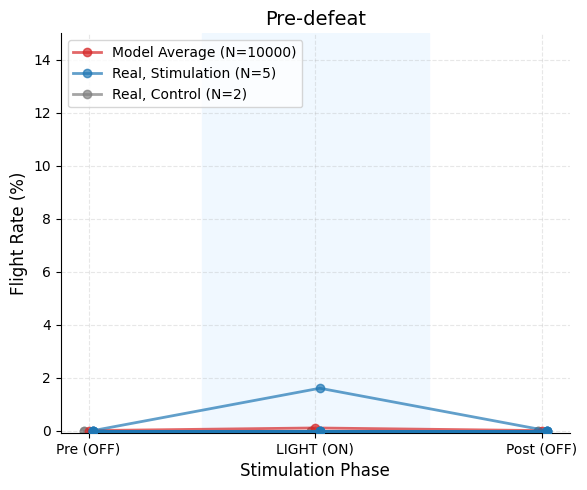

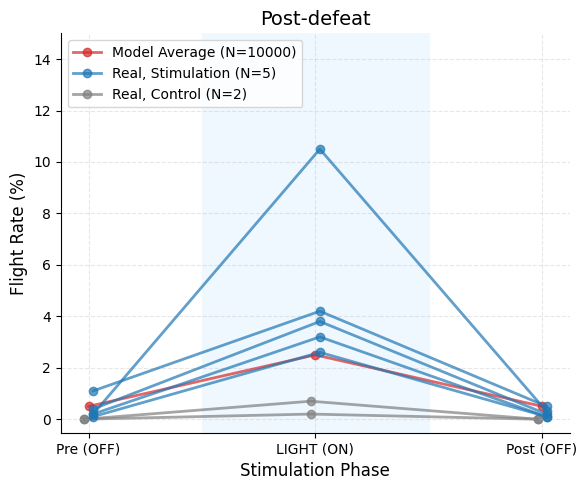

In [128]:
def plot_repeated_lines(data_list, cond, save=False):
    phases_labels = ["Pre (OFF)", "LIGHT (ON)", "Post (OFF)"]
    phases_indices = [0, 1, 2] # We need numbers to apply math/offsets
    
    color_map = {
        "Real, Stimulation (N=5)": "tab:blue",
        "Model Average (N=10000)": "tab:red",
        "Real, Control (N=2)": "tab:grey"
    }
    
    # 1. Add offsets so lines don't overlap perfectly
    x_offsets = {
        "Real, Stimulation (N=5)": 0.02,  # Shift Blue slightly right
        "Real, Control (N=2)": -0.02,     # Shift Grey slightly left
        "Model Average (N=10000)": 0.0    # Keep Red centered
    }
    
    # 2. Add Z-order to ensure Blue (ChR2) is always plotted on top of Grey
    z_orders = {
        "Real, Stimulation (N=5)": 3,
        "Model Average (N=10000)": 2,
        "Real, Control (N=2)": 1
    }

    fig, ax = plt.subplots(figsize=(6, 5)) # Adjusted size for typical publication ratio
    ax.axvspan(0.5, 1.5, color='aliceblue', alpha=1.0, zorder=0, label='_nolegend_')
    seen_labels = set()
    
    for label, values in data_list:
        line_color = color_map.get(label, "black")
        
        # Determine the shifted X coordinates for this specific line
        shift = x_offsets.get(label, 0)
        x_coords = [i + shift for i in phases_indices]
        
        # Determine label logic (only label the first instance of each group)
        lbl = label if label not in seen_labels else "_nolegend_"
        
        # Determine z-order
        z = z_orders.get(label, 1)

        ax.plot(x_coords, values, marker='o', linewidth=2, markersize=6, 
                color=line_color, label=lbl, alpha=0.7, zorder=z)
        
        seen_labels.add(label)

    # Formatting
    ax.set_title(f"{cond}-defeat", fontsize=14)
    ax.set_ylabel("Flight Rate (%)", fontsize=12)
    ax.set_xlabel("Stimulation Phase", fontsize=12)
    ax.set_ylim(top=15)
    
    # Reset X-ticks to match the original text labels
    ax.set_xticks(phases_indices)
    ax.set_xticklabels(phases_labels)
    
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc="upper left")
    
    # Clean up
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if save:
        plt.savefig(f'opto_{cond}.svg', format='svg', bbox_inches='tight')
    plt.show()

plot_repeated_lines(results_pre, cond='Pre')
plot_repeated_lines(results_post, cond='Post')